<a href="https://colab.research.google.com/github/navvod/IT4060-ML-Assignment/blob/main/Decision_Tree_Colab_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Recommendation — Algorithm 1: Decision Tree

**Dataset:** Crop Recommendation Dataset  
**Source:** https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset  
**Type:** Supervised Learning — Multi-class Classification  
**Algorithm:** Decision Tree Classifier  

---

In [ ]:
# CELL 1 — Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
# CELL 2 — Load Dataset
df = pd.read_csv('/content/Crop_recommendation.csv')
print(f'Dataset loaded!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded!
Shape: 2200 rows × 8 columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# CELL 3 — Prepare Features & Target
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# Encode target labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Features shape : {X.shape}')
print(f'Target classes : {len(le.classes_)}')
print(f'Classes        : {list(le.classes_)}')

Features shape : (2200, 7)
Target classes : 22
Classes        : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [ ]:
#  CELL 4 — Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'Split ratio    : 80% train / 20% test')

Training set   : 1760 samples
Test set       : 440 samples
Split ratio    : 80% train / 20% test


In [ ]:
# CELL 5 — Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print('✅ Decision Tree trained!')
print(f'Tree depth     : {dt_model.get_depth()}')
print(f'Total leaves   : {dt_model.get_n_leaves()}')

✅ Decision Tree trained!
Tree depth     : 17
Total leaves   : 38


In [ ]:
#  CELL 6 Hyperparameter Tuning with GridSearchCV
param_grid = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n Best Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy   : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 90 candidates, totalling 450 fits

 Best Parameters : {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy   : 0.9858


In [ ]:
# CELL 7 — Train Best Model
best_dt = grid_search.best_estimator_

print('Best Decision Tree model ready!')
print(f'Tree depth   : {best_dt.get_depth()}')
print(f'Total leaves : {best_dt.get_n_leaves()}')

Best Decision Tree model ready!
Tree depth   : 16
Total leaves : 36


In [ ]:
# CELL 8 — Predictions
y_pred       = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)

print('Predictions generated!')
print(f'Sample predictions (encoded) : {y_pred[:10]}')
print(f'Sample predictions (labels)  : {list(le.inverse_transform(y_pred[:10]))}')

Predictions generated!
Sample predictions (encoded) : [16  1  6 11 16  3 20  2  1 16]
Sample predictions (labels)  : ['orange', 'banana', 'cotton', 'maize', 'orange', 'chickpea', 'rice', 'blackgram', 'banana', 'orange']


In [ ]:
# CELL 9 — Cross Validation
cv_scores = cross_val_score(best_dt, X, y_encoded, cv=10, scoring='accuracy')

print('=== 10-Fold Cross Validation ===')
print(f'Scores     : {np.round(cv_scores, 4)}')
print(f'Mean       : {cv_scores.mean():.4f}')
print(f'Std Dev    : {cv_scores.std():.4f}')

=== 10-Fold Cross Validation ===
Scores     : [0.9864 0.9864 0.9955 0.9909 0.9955 0.9909 0.9955 0.9955 0.9818 0.9864]
Mean       : 0.9905
Std Dev    : 0.0047


In [ ]:
#  CELL 10 — Evaluation Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print('=' * 45)
print('     DECISION TREE — EVALUATION METRICS')
print('=' * 45)
print(f'  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision (wtd)   : {precision:.4f}')
print(f'  Recall (wtd)      : {recall:.4f}')
print(f'  F1 Score (wtd)    : {f1:.4f}')
print(f'  ROC-AUC (ovr)     : {roc_auc:.4f}')
print(f'  CV Mean Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 45)

     DECISION TREE — EVALUATION METRICS
  Accuracy          : 0.9795  (97.95%)
  Precision (wtd)   : 0.9806
  Recall (wtd)      : 0.9795
  F1 Score (wtd)    : 0.9794
  ROC-AUC (ovr)     : 0.9905
  CV Mean Accuracy  : 0.9905 ± 0.0047


In [ ]:
# CELL 11 — Classification Report
print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Full Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00   

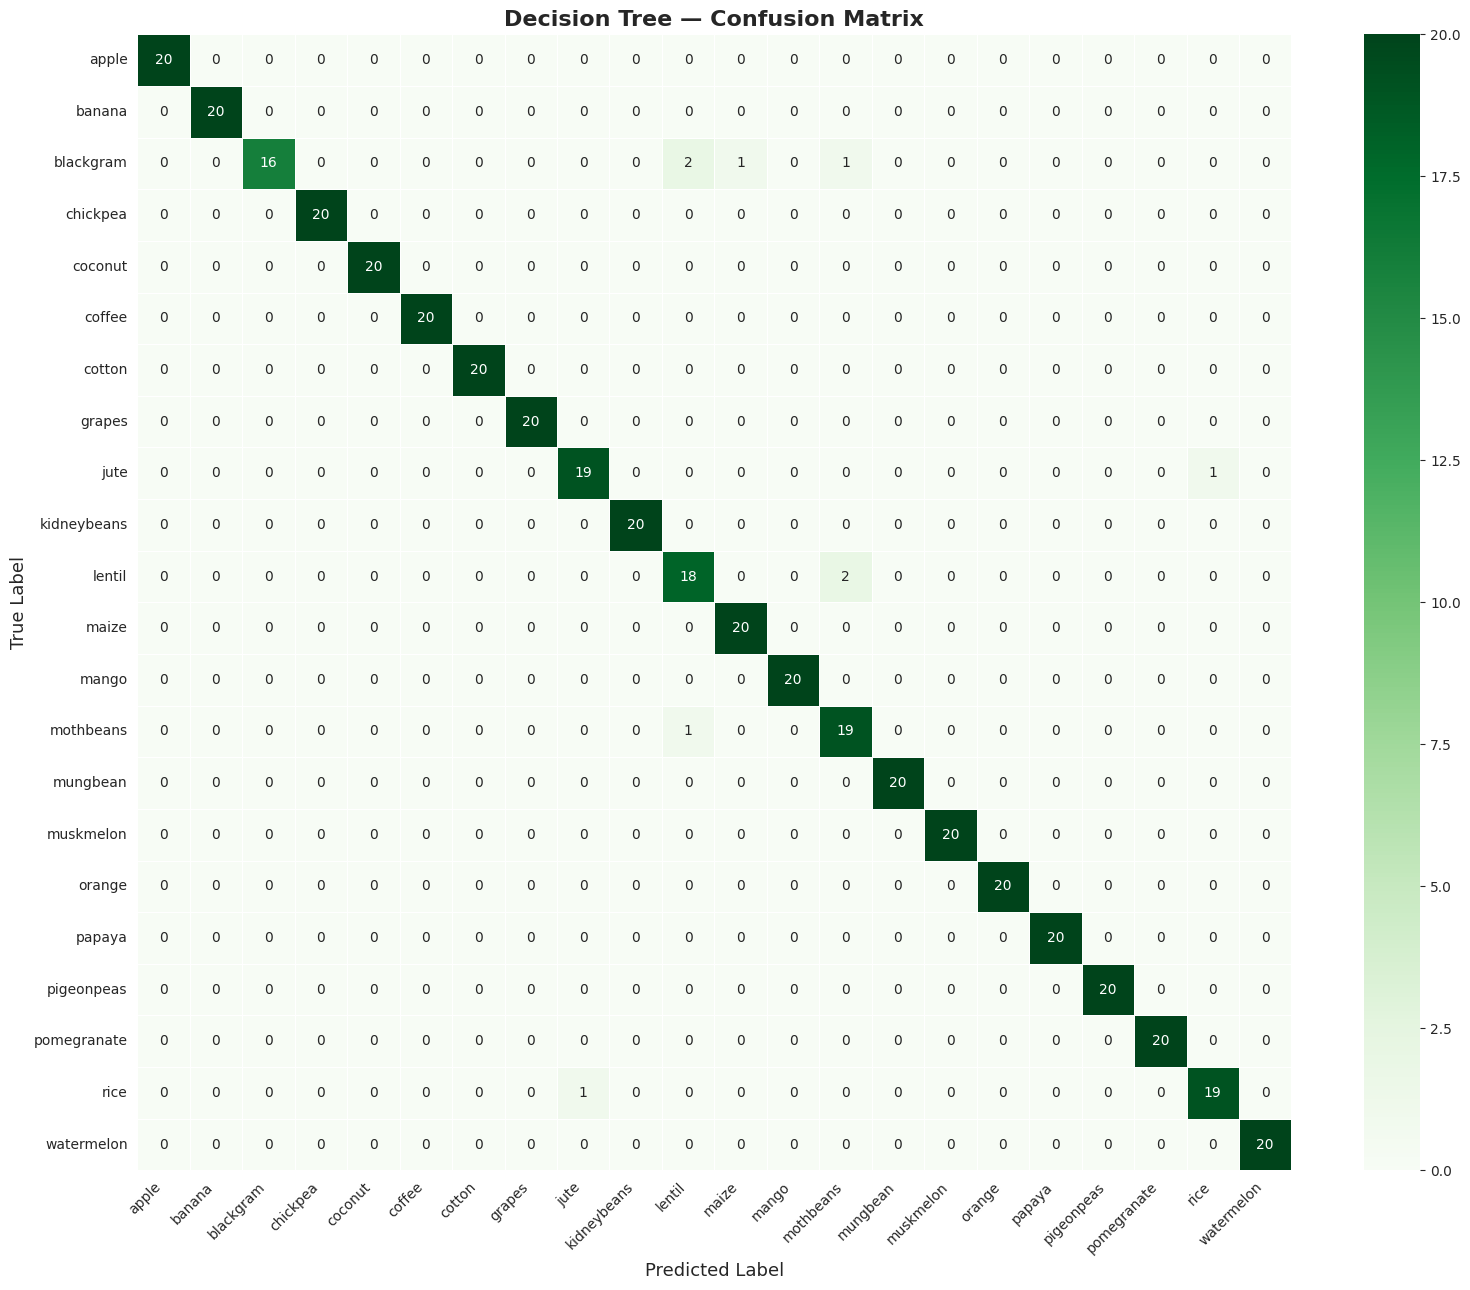

In [ ]:
#  CELL 12 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Decision Tree — Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

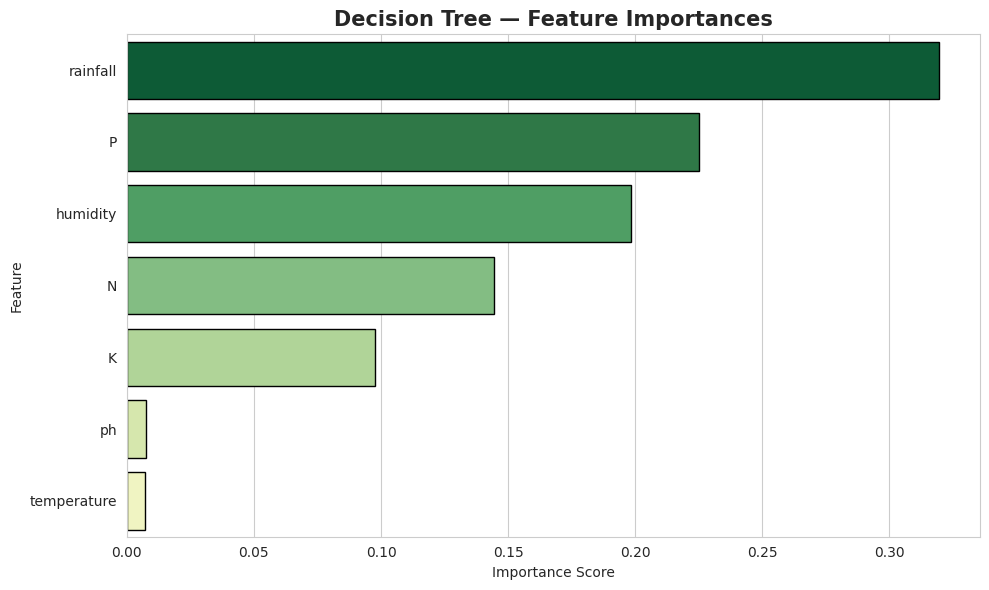

    Feature  Importance
   rainfall    0.319636
          P    0.225141
   humidity    0.198386
          N    0.144406
          K    0.097726
         ph    0.007416
temperature    0.007288


In [ ]:
#  CELL 13 — Feature Importances
feature_names = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
importances   = best_dt.feature_importances_
feat_imp_df   = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df   = feat_imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette='YlGn_r', edgecolor='black')
plt.title('Decision Tree — Feature Importances', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feat_imp_df.to_string(index=False))

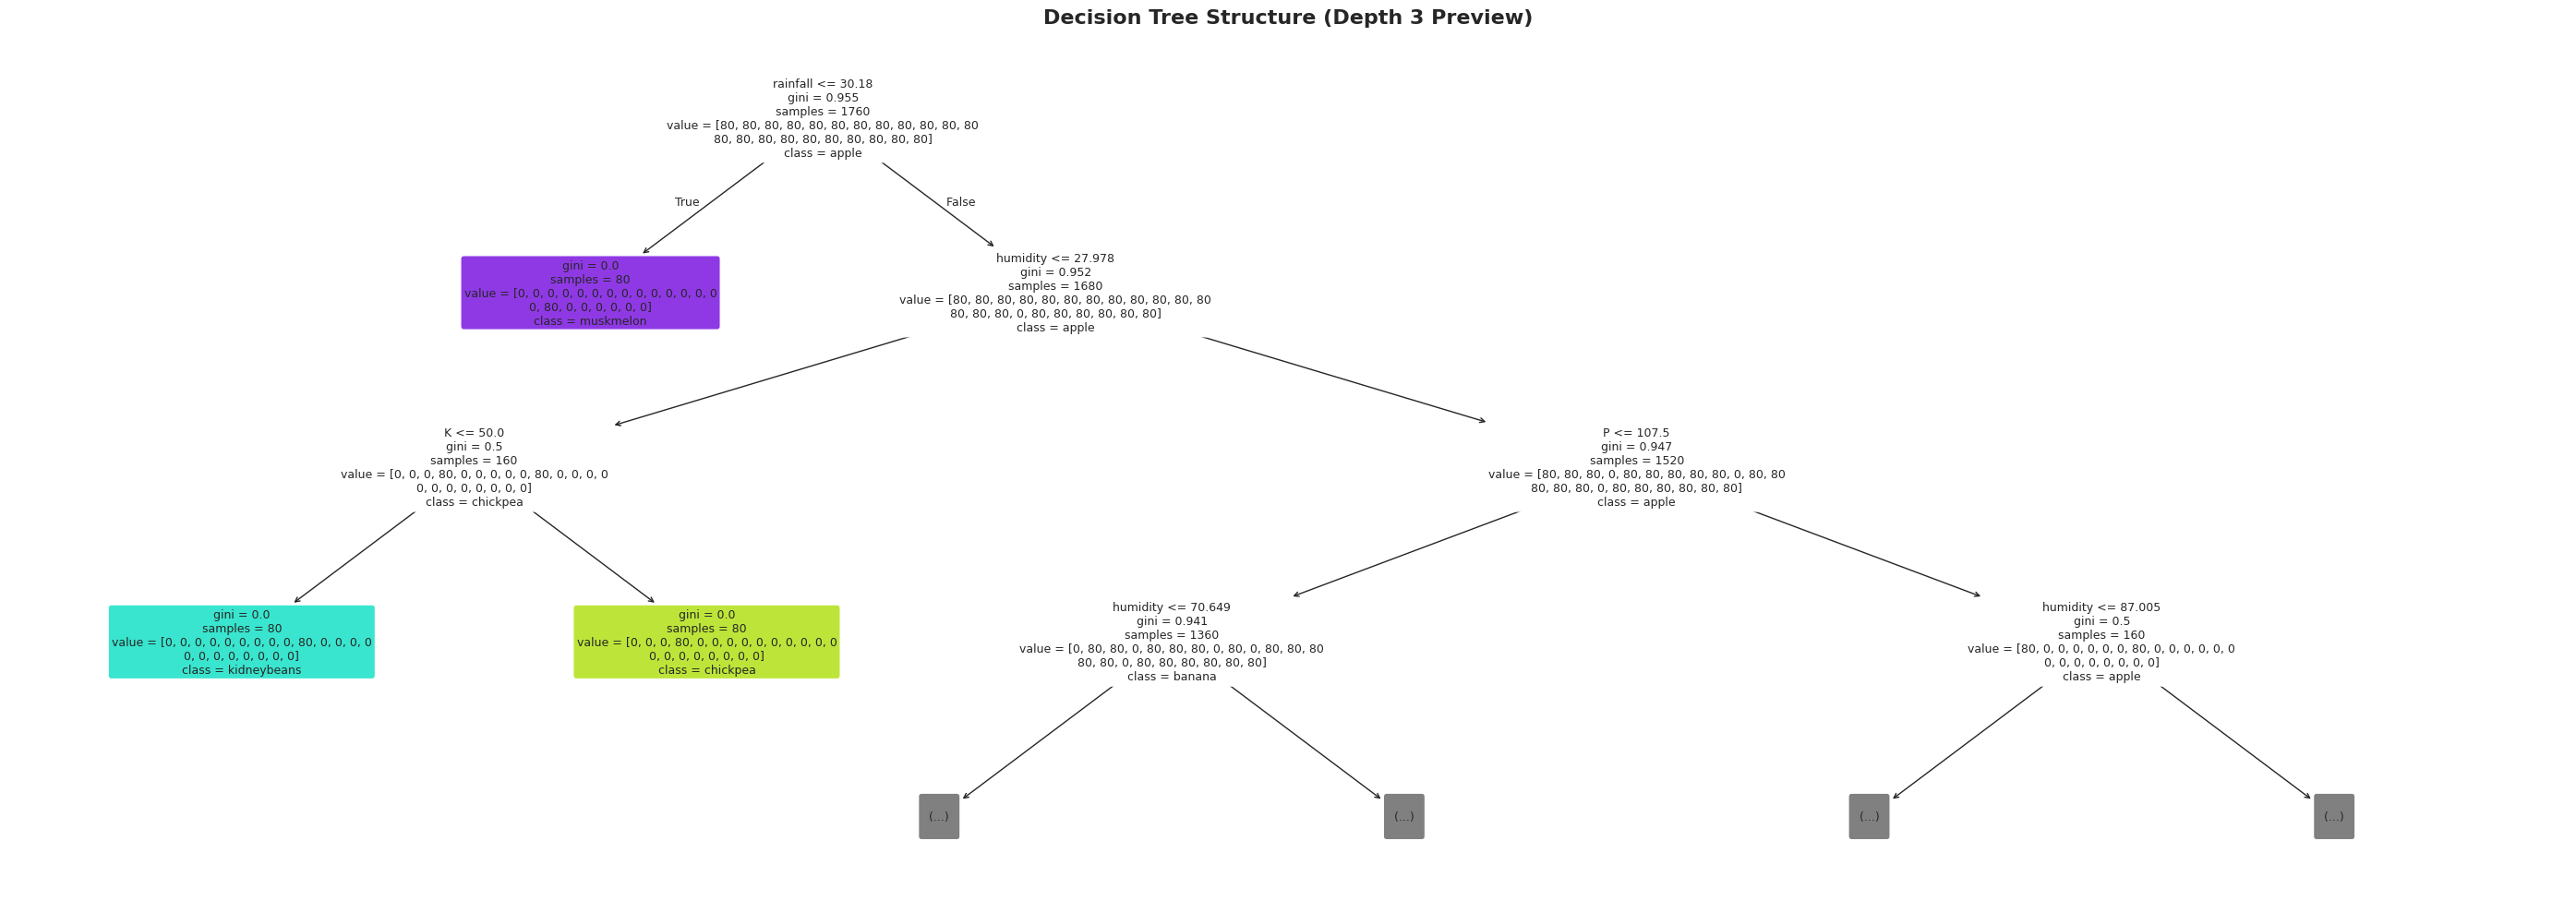

In [ ]:
# CELL 14 — Visualize Decision Tree
# Plots the tree up to depth 3 for readability
plt.figure(figsize=(28, 10))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=feature_names,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree Structure (Depth 3 Preview)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

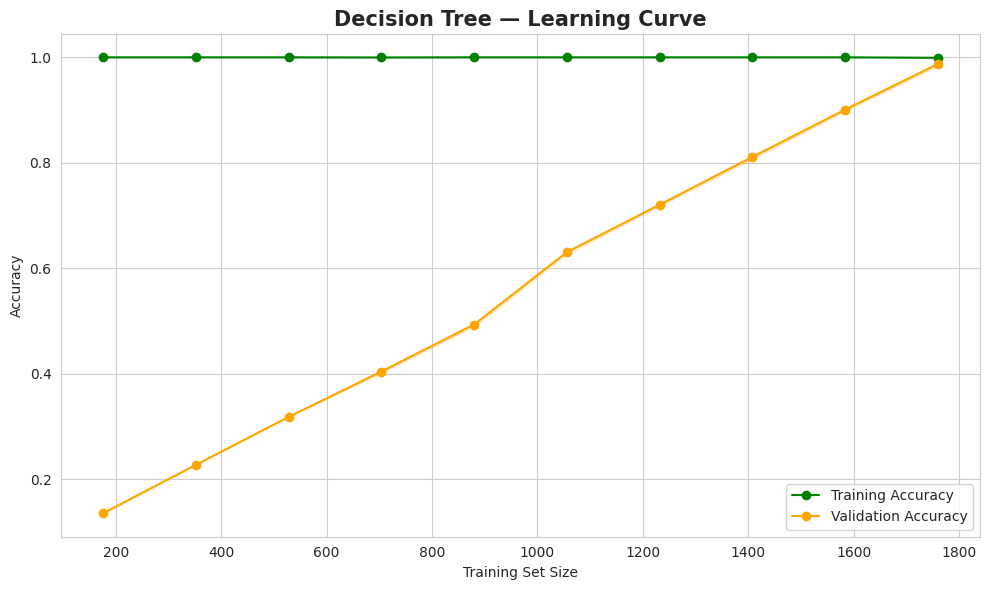

In [ ]:
# CELL 15 — Learning Curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_dt, X, y_encoded,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='green', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
plt.title('Decision Tree — Learning Curve', fontsize=15, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#  CELL 16 — Metrics Summary
metrics_dt = {
    'Algorithm' : 'Decision Tree',
    'Accuracy'  : round(accuracy, 4),
    'Precision' : round(precision, 4),
    'Recall'    : round(recall, 4),
    'F1 Score'  : round(f1, 4),
    'ROC-AUC'   : round(roc_auc, 4),
    'CV Mean'   : round(cv_scores.mean(), 4),
    'CV Std'    : round(cv_scores.std(), 4)
}

metrics_df = pd.DataFrame([metrics_dt])
print('=== Metrics Summary (copy this to your comparison notebook) ===')
print(metrics_df.to_string(index=False))

# Save to CSV so you can reuse in the final comparison notebook
metrics_df.to_csv('metrics_decision_tree.csv', index=False)
print('\n Metrics saved to metrics_decision_tree.csv')

=== Metrics Summary (copy this to your comparison notebook) ===
    Algorithm  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV Mean  CV Std
Decision Tree    0.9795     0.9806  0.9795    0.9794   0.9905   0.9905  0.0047

 Metrics saved to metrics_decision_tree.csv
